# 1. Importing the dependencies

---

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve)
import pickle

# 2. Data Loading and Understanding

---


In [12]:
df = pd.read_csv("/content/customer_churn_data.csv")
print("Shape of data:", df.shape)

Shape of data: (1000, 10)


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB
None


In [14]:
print(df.head())

   CustomerID  Age  Gender  Tenure  MonthlyCharges    ContractType  \
0           1   49    Male       4           88.35  Month-to-Month   
1           2   43    Male       0           36.67  Month-to-Month   
2           3   51  Female       2           63.79  Month-to-Month   
3           4   60  Female       8          102.34        One-Year   
4           5   42    Male      32           69.01  Month-to-Month   

  InternetService  TotalCharges TechSupport Churn  
0     Fiber Optic        353.40         Yes   Yes  
1     Fiber Optic          0.00         Yes   Yes  
2     Fiber Optic        127.58          No   Yes  
3             DSL        818.72         Yes   Yes  
4             NaN       2208.32          No   Yes  


In [15]:
print(df.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64


# **Handling Missing values**

In [37]:
# The only missing values were in InternetService column (~30%)
# All had 100% churn rate — likely customers without internet service.
# Action: fill with 'No Internet'
df['InternetService'].fillna('No Internet', inplace=True)

# Confirm no missing values remain
print(df.isnull().sum().sum())

0


# 3.**Exploratory Data Analysis (EDA)**

---



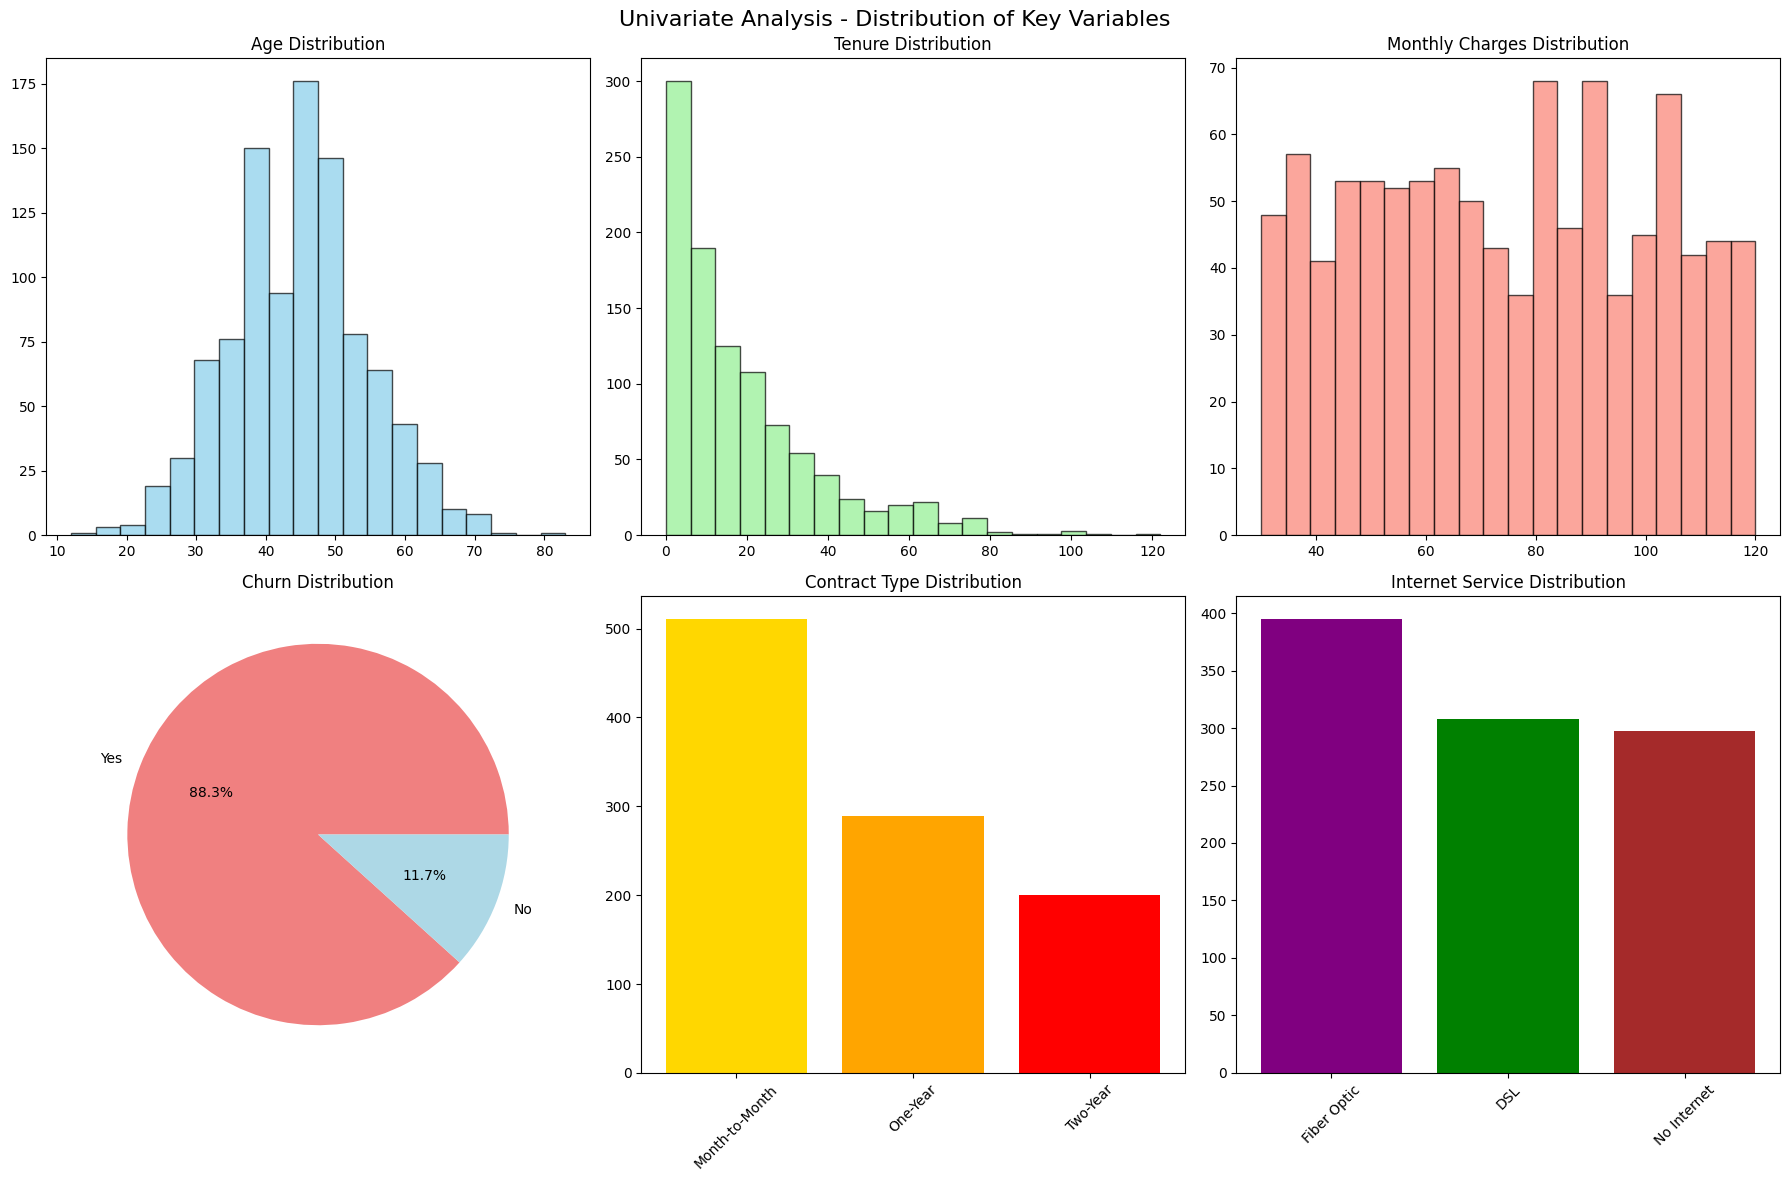

In [38]:
# Univariate Distribution Plots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Univariate Analysis - Distribution of Key Variables', fontsize=16)

# Age
axes[0,0].hist(df['Age'], bins=20, color='skyblue', alpha=0.7, edgecolor='black')
axes[0,0].set_title('Age Distribution')

# Tenure
axes[0,1].hist(df['Tenure'], bins=20, color='lightgreen', alpha=0.7, edgecolor='black')
axes[0,1].set_title('Tenure Distribution')

# Monthly Charges
axes[0,2].hist(df['MonthlyCharges'], bins=20, color='salmon', alpha=0.7, edgecolor='black')
axes[0,2].set_title('Monthly Charges Distribution')

# Churn
churn_counts = df['Churn'].value_counts()
axes[1,0].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
axes[1,0].set_title('Churn Distribution')

# Contract Type
contract_counts = df['ContractType'].value_counts()
axes[1,1].bar(contract_counts.index, contract_counts.values, color=['gold', 'orange', 'red'])
axes[1,1].set_title('Contract Type Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

# Internet Service
internet_counts = df['InternetService'].value_counts()
axes[1,2].bar(internet_counts.index, internet_counts.values, color=['purple', 'green', 'brown'])
axes[1,2].set_title('Internet Service Distribution')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**UNIVARIATE INSIGHTS**
1.   Age is roughly normally distributed around 45 years.
2.   Tenure is right-skewed, indicating many customers are relatively new.
3.   Monthly charges show a bimodal pattern, with peaks around $50 and $80.
4.   The churn rate is very high at 88.3%.
5.   Most customers are on month-to-month contracts.



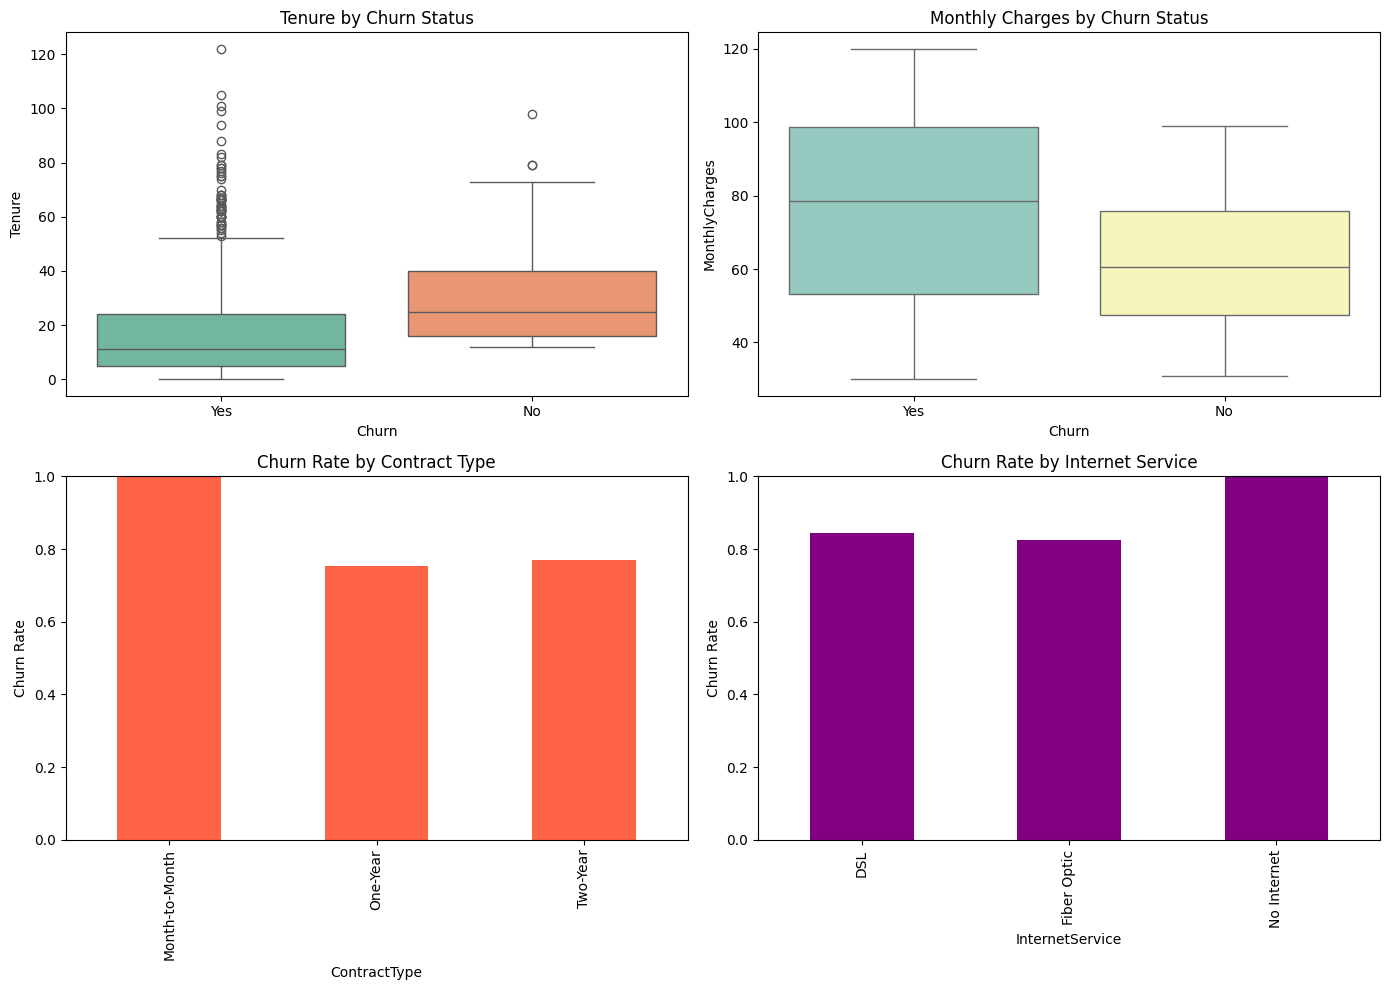

In [42]:
# Bivariate Distribution Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Tenure by Churn Status
sns.boxplot(ax=axes[0, 0], x='Churn', y='Tenure', hue='Churn', data=df, palette='Set2', legend=False)
axes[0, 0].set_title('Tenure by Churn Status')

# Plot 2: Monthly Charges by Churn Status
sns.boxplot(ax=axes[0, 1], x='Churn', y='MonthlyCharges', hue='Churn', data=df, palette='Set3', legend=False)
axes[0, 1].set_title('Monthly Charges by Churn Status')

# Plot 3: Churn Rate by Contract Type
contract_churn = df.groupby('ContractType')['Churn'].value_counts(normalize=True).unstack().fillna(0)
contract_churn['Yes'].plot(kind='bar', color='tomato', ax=axes[1, 0])
axes[1, 0].set_title('Churn Rate by Contract Type')
axes[1, 0].set_ylabel('Churn Rate')
axes[1, 0].set_ylim(0, 1)

# Plot 4: Churn Rate by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack().fillna(0)
internet_churn['Yes'].plot(kind='bar', color='purple', ax=axes[1, 1])
axes[1, 1].set_title('Churn Rate by Internet Service')
axes[1, 1].set_ylabel('Churn Rate')
axes[1, 1].set_ylim(0, 1)

# Adjust layout
plt.tight_layout()
plt.show()

**BIVARIATE INSIGHTS**
1.   Customers who churn tend to have lower tenure and higher monthly charges.
2.   Month-to-Month contracts have the highest churn rate.
3.   Fiber Optic customers are more likely to churn than DSL or Unknown.

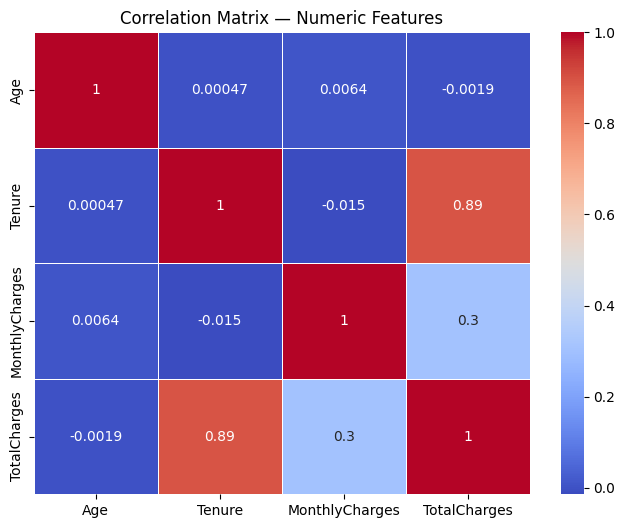

In [45]:
# Correlation Matrix — Numeric Features
plt.figure(figsize=(8,6))
corr = df[['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.show()

**EDA COMPLETE. Key findings**
1.   High churn rate (88.3%) suggests retention issues
2.   New customers (low tenure) churn more frequently
3.   Higher monthly charges correlate with increased churn
4.   Month-to-month contracts show highest churn risk
5.   Fiber optic service has higher churn than DSL



# **Data Preprocessing**

In [22]:
# 📦 Feature Engineering & Preprocessing
df_model = df.drop('CustomerID', axis=1)

In [23]:
# Encode Target
le = LabelEncoder()
df_model['Churn'] = le.fit_transform(df_model['Churn'])  # Yes=1, No=0

In [24]:
# Split features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

In [25]:
# Define categorical and numerical columns
cat_features = ['Gender', 'ContractType', 'InternetService', 'TechSupport']
num_features = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']

In [26]:
# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ])

In [27]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# Apply Preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# **Model Building — Random Forest**

In [52]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train_processed, y_train)

RandomForestClassifier(random_state=42)

In [53]:
y_pred_rf = rfc.predict(X_test_processed)
y_proba_rf = rfc.predict_proba(X_test_processed)[:, 1]

In [54]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.995

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       0.99      1.00      1.00       177

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200



# **Model Building — Logistic Regression**

In [48]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [49]:
y_pred_lr = lr.predict(X_test_processed)
y_proba_lr = lr.predict_proba(X_test_processed)[:, 1]

In [50]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.94

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.48      0.65        23
           1       0.94      1.00      0.97       177

    accuracy                           0.94       200
   macro avg       0.97      0.74      0.81       200
weighted avg       0.94      0.94      0.93       200



# **AUC Score Comparison + ROC Curves**

Random Forest AUC: 1.000
Logistic Regression AUC: 0.991


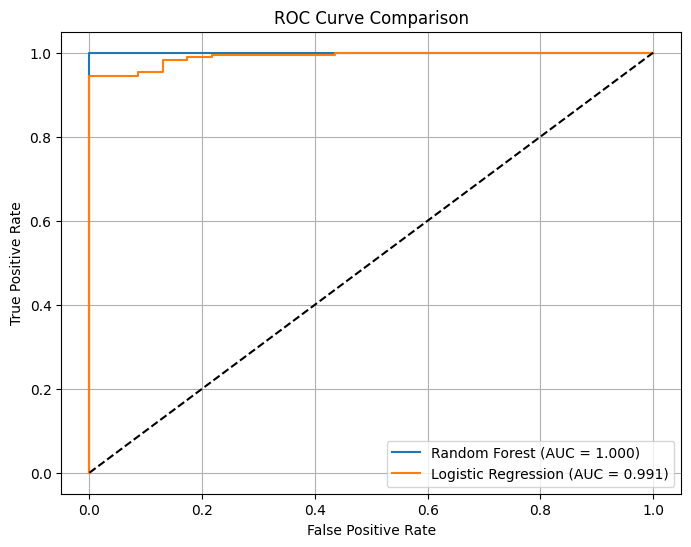

In [55]:
# AUC Scores
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Random Forest AUC: {auc_rf:.3f}")
print(f"Logistic Regression AUC: {auc_lr:.3f}")

# ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid()
plt.show()

# **Feature Importance**



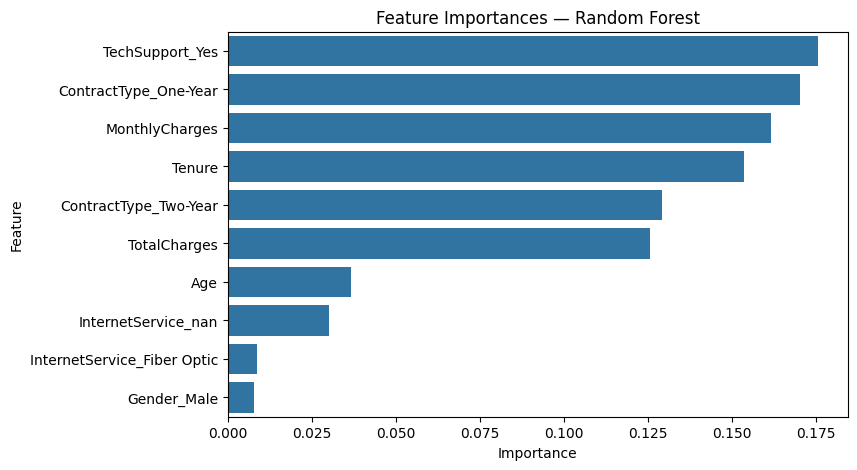

In [56]:
importances = rfc.feature_importances_
feature_names = (preprocessor.named_transformers_['num'].get_feature_names_out(num_features).tolist() +
                 preprocessor.named_transformers_['cat'].get_feature_names_out().tolist())

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importances — Random Forest")
plt.show()

# **Saving the model**

In [58]:
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rfc, file)